In [3]:
print("CS130 Analysis Notebook")


CS130 Analysis Notebook


In [48]:
with open("construction_spending.csv", "r") as file:
    data = file.readlines()

print(data[:5])



['"time.index","time.month","time.month name","time.period","time.year","annual.combined.amusement and recreation","annual.combined.commercial","annual.combined.communication","annual.combined.conservation and development","annual.combined.educational","annual.combined.health care","annual.combined.highway and street","annual.combined.lodging","annual.combined.manufacturing","annual.combined.nonresidential","annual.combined.office","annual.combined.power","annual.combined.public safety","annual.combined.religious","annual.combined.residential","annual.combined.sewage and waste disposal","annual.combined.total construction","annual.combined.transportation","annual.combined.water supply","annual.private.amusement and recreation","annual.private.commercial","annual.private.communication","annual.private.conservation and development","annual.private.educational","annual.private.health care","annual.private.highway and street","annual.private.lodging","annual.private.manufacturing","annual.

In [4]:
import pandas as pd

construction = pd.read_csv("construction_spending.csv")
construction.head()

,time.index,time.month,time.month name,time.period,time.year,annual.combined.amusement and recreation,annual.combined.commercial,annual.combined.communication,annual.combined.conservation and development,annual.combined.educational,...,current.public.nonresidential,current.public.office,current.public.power,current.public.public safety,current.public.religious,current.public.residential,current.public.sewage and waste disposal,current.public.total construction,current.public.transportation,current.public.water supply
0,1,1,Jan,Jan2002,2002,17866,68254,18873,3603,72357,...,13844,697,273,637,0,400,1127,14243,1285,826
1,2,2,Feb,Feb2002,2002,18317,65840,19943,3712,74336,...,13691,661,284,640,0,423,1119,14113,1318,851
2,3,3,Mar,Mar2002,2002,17988,66722,19092,3332,72247,...,13967,728,222,626,0,420,1182,14386,1452,865
3,4,4,Apr,Apr2002,2002,17264,64879,19150,3076,74553,...,15791,798,369,638,0,430,1272,16221,1479,967
4,5,5,May,May2002,2002,16988,62741,18735,3199,75577,...,17937,864,388,654,0,438,1417,18375,1652,1082


In [5]:
construction.columns

Index(['time.index', 'time.month', 'time.month name', 'time.period',
       'time.year', 'annual.combined.amusement and recreation',
       'annual.combined.commercial', 'annual.combined.communication',
       'annual.combined.conservation and development',
       'annual.combined.educational',
       ...
       'current.public.nonresidential', 'current.public.office',
       'current.public.power', 'current.public.public safety',
       'current.public.religious', 'current.public.residential',
       'current.public.sewage and waste disposal',
       'current.public.total construction', 'current.public.transportation',
       'current.public.water supply'],
      dtype='object', length=119)

In [51]:
construction[["time.year", "annual.combined.residential"]].head()

,time.year,annual.combined.residential
0,2002,382979
1,2002,391434
2,2002,390942
3,2002,404255
4,2002,399164


In [6]:
for col in construction.columns:
    if "month" in col.lower():
        print(col)
    if "total construction" in col.lower():
        print(col)

time.month
time.month name
annual.combined.total construction
annual.private.total construction
annual.public.total construction
current.combined.total construction
current.private.total construction
current.public.total construction


In [7]:
summer = construction[construction["time.month"].isin([6, 7, 8])]
winter = construction[construction["time.month"].isin([12, 1, 2])]

summer_avg = summer["annual.combined.total construction"].mean()
winter_avg = winter["annual.combined.total construction"].mean()

print("Summer average:", summer_avg)
print("Winter average:", winter_avg)

Summer average: 973317.7142857143
Winter average: 968313.3255813953


In [8]:
residential_avg = construction["annual.combined.residential"].mean()
nonresidential_avg = construction["annual.combined.nonresidential"].mean()

print("Residential avg:", residential_avg)
print("Nonresidential avg:", nonresidential_avg)

Residential avg: 404727.08875739644
Nonresidential avg: 566181.0650887574


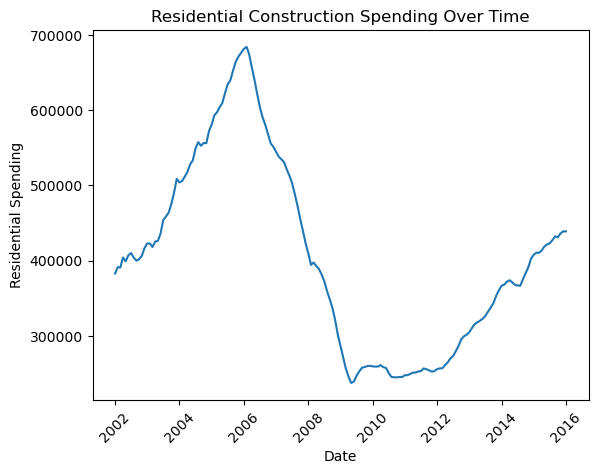

In [9]:
import matplotlib.pyplot as plt

construction["date"] = pd.to_datetime(
    construction["time.year"].astype(str) + "-" + construction["time.month"].astype(str) + "-01"
)

construction = construction.sort_values("date")

plt.figure()
plt.plot(construction["date"], construction["annual.combined.residential"])
plt.title("Residential Construction Spending Over Time")
plt.xlabel("Date")
plt.ylabel("Residential Spending")
plt.xticks(rotation=45)
plt.savefig("graph1.png")
plt.show()


In [10]:
monthly_avg = construction.groupby("time.month")["annual.combined.total construction"].mean()
print(monthly_avg)

time.month
1     967960.266667
2     958477.071429
3     961565.000000
4     965960.428571
5     969352.428571
6     972730.714286
7     973190.642857
8     974031.785714
9     975376.357143
10    977881.214286
11    976063.285714
12    978527.857143
Name: annual.combined.total construction, dtype: float64


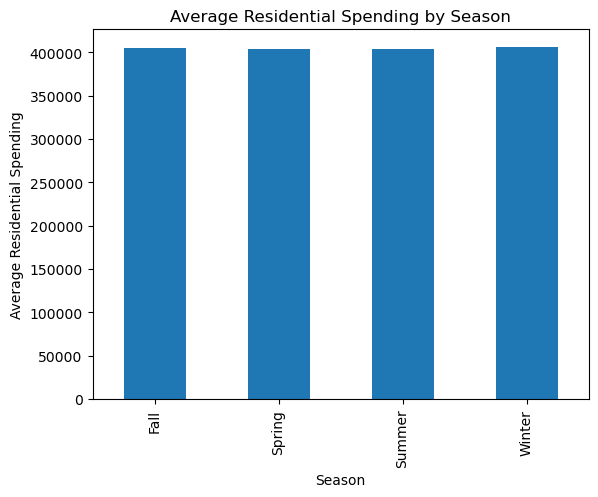

In [11]:
construction["season"] = ""

for i in construction.index:
    month = construction.loc[i, "time.month"]
    
    if month in [12, 1, 2]:
        construction.loc[i, "season"] = "Winter"
    elif month in [3, 4, 5]:
        construction.loc[i, "season"] = "Spring"
    elif month in [6, 7, 8]:
        construction.loc[i, "season"] = "Summer"
    else:
        construction.loc[i, "season"] = "Fall"

season_avg = construction.groupby("season")["annual.combined.residential"].mean()

plt.figure()
season_avg.plot(kind="bar")
plt.title("Average Residential Spending by Season")
plt.xlabel("Season")
plt.ylabel("Average Residential Spending")
plt.savefig("graph2.png")
plt.show()

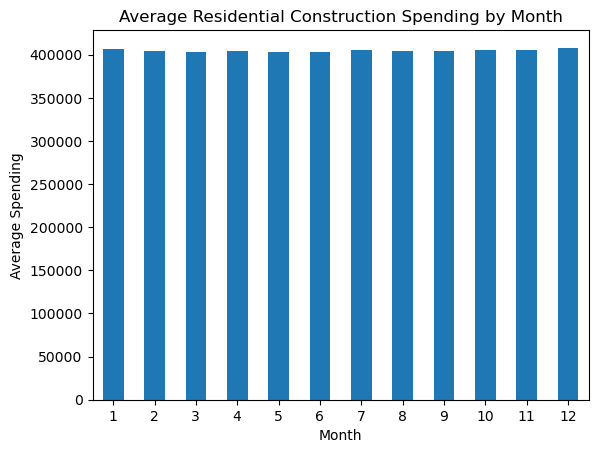

In [12]:
monthly_avg = construction.groupby("time.month")["annual.combined.residential"].mean()


monthly_avg = monthly_avg.sort_index()

# graph
plt.figure()
monthly_avg.plot(kind="bar")
plt.title("Average Residential Construction Spending by Month")
plt.xlabel("Month")
plt.ylabel("Average Spending")
plt.xticks(rotation=0)
plt.savefig("graph4.png")
plt.show()

In [27]:
private_avg = construction["annual.private.total construction"].mean()
public_avg = construction["annual.public.total construction"].mean()

print("Private avg:", private_avg)
print("Public avg:", public_avg)

Private avg: 702554.1538461539
Public avg: 268354.5917159763


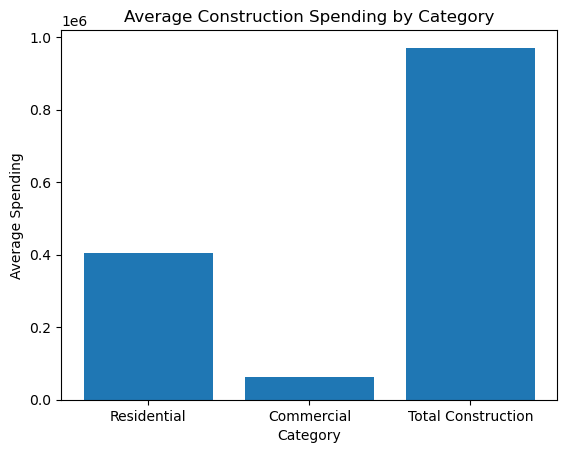

In [13]:
residential_avg = construction["annual.combined.residential"].mean()
commercial_avg = construction["annual.combined.commercial"].mean()
total_avg = construction["annual.combined.total construction"].mean()

categories = ["Residential", "Commercial", "Total Construction"]
averages = [residential_avg, commercial_avg, total_avg]

plt.figure()
plt.bar(categories, averages)
plt.title("Average Construction Spending by Category")
plt.xlabel("Category")
plt.ylabel("Average Spending")
plt.savefig("graph3.png")
plt.show()

In [14]:
construction.head()
construction.shape
construction.columns

Index(['time.index', 'time.month', 'time.month name', 'time.period',
       'time.year', 'annual.combined.amusement and recreation',
       'annual.combined.commercial', 'annual.combined.communication',
       'annual.combined.conservation and development',
       'annual.combined.educational',
       ...
       'current.public.power', 'current.public.public safety',
       'current.public.religious', 'current.public.residential',
       'current.public.sewage and waste disposal',
       'current.public.total construction', 'current.public.transportation',
       'current.public.water supply', 'date', 'season'],
      dtype='object', length=121)

KeyError: 'Column not found: annual.public.highway'